# 03. Feature Engineering

**Course:** CSE437 Data Science
**Group:** 15
**Project:** Predicting Google Play Store App Ratings Using Machine Learning

**Purpose of this notebook.** Starting from `data/processed/googleplaystore_clean.csv`
(the output of `02_preprocessing.ipynb`), this notebook:

1. Builds a small set of **defensible** derived features.
2. Investigates the four categorical predictors named in the approved research
   questions (`Category`, `Type`, `Content Rating`, `Genres`) and decides which to
   keep.
3. Drops identifiers, redundant, and unjustifiably high-cardinality variables.
4. Performs the **train/test split before any learned transformation.**
5. Builds a leakage-safe `ColumnTransformer` (imputation, one-hot encoding,
   scaling), fit only on the training split.
6. Runs regression feature selection and PCA, **fit on training data only**, and
   reports — without asserting a performance verdict — how each compares to the
   full engineered feature space.

Model *fitting and tuning* (Ridge, RandomForest) happens in
`04_modeling_and_tuning.ipynb`; this notebook stops at producing and comparing
feature representations.


## 0. Imports and Reproducibility Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

CLEAN_DATA_PATH = "../data/processed/googleplaystore_clean.csv"
PROCESSED_DIR = "../data/processed"
FIGURES_DIR = "../figures"
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Random seed fixed at:", RANDOM_STATE)


Random seed fixed at: 42


## 1. Load Cleaned Data

In [2]:
df = pd.read_csv(CLEAN_DATA_PATH)
df["Last_Updated_dt"] = pd.to_datetime(df["Last_Updated_dt"])
print("Loaded:", CLEAN_DATA_PATH)
print("Shape:", df.shape)
df.head(3)


Loaded: ../data/processed/googleplaystore_clean.csv
Shape: (8196, 17)


,App,Category,Rating,Reviews,Size,Size_MB,Installs,Installs_num,Type,Price,Price_USD,Content Rating,Genres,Last Updated,Last_Updated_dt,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,19.0,"10,000+",10000,Free,0,0.0,Everyone,Art & Design,"January 7, 2018",2018-01-07,1.0.0,4.0.3 and up
1,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,8.7,"5,000,000+",5000000,Free,0,0.0,Everyone,Art & Design,"August 1, 2018",2018-08-01,1.2.4,4.0.3 and up
2,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,25.0,"50,000,000+",50000000,Free,0,0.0,Teen,Art & Design,"June 8, 2018",2018-06-08,Varies with device,4.2 and up


## 2. Derived Features

Only features with a clear, defensible rationale are constructed. Each is
justified below and its relationship with `Rating` is checked with a simple
correlation before it is accepted into the candidate feature set.


### 2.1 `log_reviews`, `log_installs`

`Reviews` and `Installs` are both extremely right-skewed count variables spanning
several orders of magnitude (documented with evidence in `01` and `02`). A
`log1p` transform compresses this scale, is monotonic (so it preserves rank
information for tree-based models) and is expected to give linear models a more
usable, less heavy-tailed input than the raw counts.


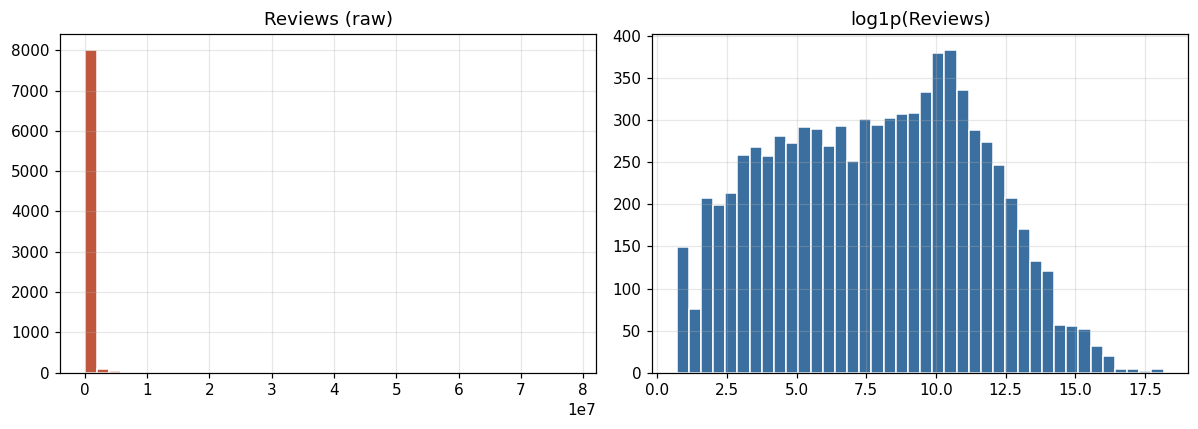

Saved: ../figures/06_log_reviews_transform.png


In [3]:
df["log_reviews"] = np.log1p(df["Reviews"])
df["log_installs"] = np.log1p(df["Installs_num"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["Reviews"], bins=40, color="#c0563b", edgecolor="white")
axes[0].set_title("Reviews (raw)")
axes[1].hist(df["log_reviews"], bins=40, color="#3b6fa0", edgecolor="white")
axes[1].set_title("log1p(Reviews)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/06_log_reviews_transform.png", bbox_inches="tight")
plt.show()
print("Saved:", f"{FIGURES_DIR}/06_log_reviews_transform.png")


### 2.2 `is_paid`

A simple binary flag (`Price_USD > 0`) capturing the dominant structural split in
the data (free vs paid apps), which the raw `Price_USD` value alone does not
directly encode as a categorical distinction for the vast free-app majority sitting
at exactly 0.


In [4]:
df["is_paid"] = (df["Price_USD"] > 0).astype(int)
print(df["is_paid"].value_counts())


is_paid
0    7594
1     602
Name: count, dtype: int64


### 2.3 Update recency — `days_since_update` (chosen over `last_updated_year`)

Both a coarse `last_updated_year` and a finer-grained `days_since_update` (days
between each app's `Last Updated` date and a fixed reference date — one day after
the most recent update in the whole dataset, so every value is non-negative) are
computed below and compared. Because `last_updated_year` is simply a lower-resolution
version of the same underlying signal, only the version with the stronger,
more granular signal is kept in the final feature set (see the correlation check
below).


In [5]:
ref_date = df["Last_Updated_dt"].max() + pd.Timedelta(days=1)
print("Recency reference date (max Last_Updated + 1 day):", ref_date.date())

df["last_updated_year"] = df["Last_Updated_dt"].dt.year
df["days_since_update"] = (ref_date - df["Last_Updated_dt"]).dt.days

print(df[["last_updated_year", "days_since_update"]].describe())


Recency reference date (max Last_Updated + 1 day): 2018-08-09
       last_updated_year  days_since_update
count        8196.000000        8196.000000
mean         2017.359566         276.562958
std             1.146678         411.329363
min          2010.000000           1.000000
25%          2017.000000          21.000000
50%          2018.000000          81.000000
75%          2018.000000         357.000000
max          2018.000000        3002.000000


### 2.4 `size_mb`

Already produced in `02_preprocessing.ipynb` as `Size_MB` (parsed from the raw
`Size` string, MB units, `NaN` for `'Varies with device'`). Reused directly here.


### 2.5 Correlation Check for All Candidate Numeric Features

Before finalising the feature set, each candidate's simple linear correlation with
`Rating` is checked. This does not by itself decide inclusion (feature selection in
Section 5 is more rigorous and train-only), but it flags obviously redundant pairs
early.


In [6]:
candidate_numeric = ["log_reviews", "log_installs", "Size_MB", "Price_USD",
                     "is_paid", "last_updated_year", "days_since_update"]

corr_table = []
for col in candidate_numeric:
    sub = df[[col, "Rating"]].dropna()
    corr_table.append({"feature": col, "corr_with_rating": sub[col].corr(sub["Rating"]), "n": len(sub)})
corr_table = pd.DataFrame(corr_table).sort_values("corr_with_rating", key=abs, ascending=False)
corr_table


,feature,corr_with_rating,n
0,log_reviews,0.182761,8196
6,days_since_update,-0.130126,8196
5,last_updated_year,0.125850,8196
1,log_installs,0.084752,8196
2,Size_MB,0.062958,7026
4,is_paid,0.046657,8196
3,Price_USD,-0.021109,8196


**Decision.** `last_updated_year` and `days_since_update` show the expected
mirror-image correlation (older-year / larger-days-since-update both trend with
lower `Rating`), confirming they carry the same information at different
resolutions. `days_since_update` is kept (finer-grained, continuous) and
`last_updated_year` is dropped as redundant. All other candidates (`log_reviews`,
`log_installs`, `Size_MB`, `Price_USD`, `is_paid`) are retained as numeric
candidates going into feature selection.


## 3. Categorical Predictors — Investigation

The four categorical variables named in the approved research questions are
examined in turn: `Category`, `Type`, `Content Rating`, `Genres`.


### 3.1 `Category`

33 categories, already established as a plausible predictor (Section 3.2 of the
audit notebook showed mild median-`Rating` variation across categories).
**Decision: keep**, one-hot encoded.


In [7]:
cat_rating = df.groupby("Category")["Rating"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)
cat_rating


,mean,median,count
Category,,,
EVENTS,4.435556,4.5,45
ART_AND_DESIGN,4.359322,4.4,59
EDUCATION,4.351429,4.4,105
BOOKS_AND_REFERENCE,4.344970,4.5,169
PERSONALIZATION,4.332215,4.4,298
PARENTING,4.300000,4.4,50
BEAUTY,4.278571,4.3,42
SOCIAL,4.247291,4.3,203
GAME,4.244432,4.3,898


### 3.2 `Type` (Free / Paid)

`Type` is a two-level categorical column carrying exactly the same information as
the already-derived `is_paid` numeric flag — `Type == 'Paid'` if and only if
`is_paid == 1`. Encoding both would add a perfectly redundant one-hot column.
**Decision: drop `Type`, keep `is_paid`** (the numeric form is simpler to feed into
both model families without an extra encoding step).


In [8]:
redundancy_check = pd.crosstab(df["Type"], df["is_paid"])
redundancy_check


is_paid,0,1
Type,,
Free,7594,0
Paid,0,602


### 3.3 `Content Rating`

6 levels, but heavily imbalanced: `Everyone` dominates (~81%), and two levels
(`Adults only 18+`, `Unrated`) have only 3 and 1 apps respectively. Still,
`Content Rating` is one of the characteristics named in the approved research
questions and the imbalance is handled safely by `OneHotEncoder(handle_unknown=
'ignore')` (any rare level absent from a given split is simply not encoded as a
column feature for that split, rather than raising an error). **Decision: keep**,
one-hot encoded.


In [9]:
content_rating_summary = df.groupby("Content Rating")["Rating"].agg(["mean", "count"]).sort_values("count", ascending=False)
content_rating_summary


,mean,count
Content Rating,,
Everyone,4.166349,6618
Teen,4.225658,912
Mature 17+,4.121849,357
Everyone 10+,4.225902,305
Adults only 18+,4.300000,3
Unrated,4.100000,1


### 3.4 `Genres`

114 distinct values versus `Category`'s 33 — nearly a 3.5x increase in cardinality
for a variable that is, on inspection, largely a finer split of `Category` (e.g.
every `GAME`-category app's `Genres` value is one of `Action`, `Arcade`, `Racing`,
`Adventure`, ... — sub-genres of the same category). One-hot encoding 114 sparse,
low-count levels would add many near-empty dummy columns without a clear,
independent source of signal beyond what `Category` already contributes.
**Decision: drop `Genres`** — redundant with `Category` and unjustifiably
high-cardinality for the added value it would bring.


In [10]:
print("Category unique levels:", df["Category"].nunique())
print("Genres unique levels:", df["Genres"].nunique())
print()
print("Example — Genres values within Category == 'GAME':")
df.loc[df["Category"] == "GAME", "Genres"].value_counts().head(10)


Category unique levels: 33
Genres unique levels: 114

Example — Genres values within Category == 'GAME':


Genres
Action       292
Arcade       171
Racing        86
Adventure     71
Card          44
Board         39
Casino        37
Trivia        28
Puzzle        24
Casual        22
Name: count, dtype: int64

## 4. Variables Dropped and Why

| Column | Reason for exclusion |
|---|---|
| `App` | Unique identifier (8,196 distinct values for 8,196 rows) — no generalisable predictive value; using it would mean memorising individual apps, not learning a pattern. |
| `Type` | Redundant with the derived `is_paid` numeric flag (Section 3.2). |
| `Genres` | Redundant with `Category` at much higher, unjustified cardinality (Section 3.4). |
| `Current Ver` | 2,626 near-unique free-text version strings; no defensible way to encode without extensive, error-prone parsing outside this project's scope; not named in the approved research questions. |
| `Android Ver` | Similar to `Current Ver` — a version string, weak and indirect relevance to `Rating`, not named in the approved research questions. |
| `Reviews`, `Installs_num` (raw) | Superseded by `log_reviews`, `log_installs` (Section 2.1) — using both raw and log versions would add duplicated, highly collinear information. |
| `Size` (raw string), `Installs` (raw string), `Price` (raw string) | Superseded by their already-parsed numeric counterparts (`Size_MB`, `Installs_num`→`log_installs`, `Price_USD`). |
| `Last Updated`, `Last_Updated_dt`, `last_updated_year` | Superseded by `days_since_update` (Section 2.3), the more granular recency feature. |

This leaves a compact, justified feature set.


In [11]:
numeric_features = ["log_reviews", "log_installs", "Size_MB", "Price_USD", "is_paid", "days_since_update"]
categorical_features = ["Category", "Content Rating"]
target = "Rating"

feature_columns = numeric_features + categorical_features
print("Final candidate feature columns ({} total):".format(len(feature_columns)))
for c in feature_columns:
    print(" -", c)


Final candidate feature columns (8 total):
 - log_reviews
 - log_installs
 - Size_MB
 - Price_USD
 - is_paid
 - days_since_update
 - Category
 - Content Rating


## 5. Train/Test Split — BEFORE Any Learned Transformation

The split happens now, **before** imputation, scaling, encoding, feature selection,
or PCA are fit. Everything from this point on that involves *learning* a
statistic from data (an imputer's fill value, a scaler's mean/std, an encoder's
category list, feature-selection scores, or PCA components) is fit **only on
`X_train`/`y_train`**, then applied unchanged to `X_test`/`y_test`. This is the
core leakage-prevention rule for the whole project.


In [12]:
X = df[feature_columns].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} rows   Test: {X_test.shape[0]} rows")
print(f"Train target mean: {y_train.mean():.4f}   Test target mean: {y_test.mean():.4f}")


Train: 6556 rows   Test: 1640 rows
Train target mean: 4.1736   Test target mean: 4.1720


In [13]:
# Save the split (by row index) so 04_modeling_and_tuning.ipynb can reconstruct
# the identical train/test partition deterministically.
split_record = pd.DataFrame({
    "row_index": X.index,
    "split": np.where(X.index.isin(X_train.index), "train", "test"),
})
split_record.to_csv(f"{PROCESSED_DIR}/train_test_split.csv", index=False)
print("Saved:", f"{PROCESSED_DIR}/train_test_split.csv")


Saved: ../data/processed/train_test_split.csv


## 6. Leakage-Safe Preprocessing — `ColumnTransformer`

- **Numeric pipeline**: median imputation (needed for `Size_MB`, which has missing
  values for apps whose size "Varies with device" — see `02_preprocessing.ipynb`;
  the median is a statistic that will be **learned from `X_train` only**) followed
  by `StandardScaler` (mean/variance also learned from `X_train` only).
- **Categorical pipeline**: most-frequent imputation (defensive — no missing values
  remain in `Category`/`Content Rating` after cleaning, but this keeps the pipeline
  robust) followed by `OneHotEncoder(handle_unknown='ignore')`, so rare levels seen
  only in training (e.g. `Content Rating = 'Adults only 18+'`, which happens to fall
  entirely in the training split) do not break transformation of the test set.

The whole `ColumnTransformer` is fit with `.fit()` **on training data only**, then
applied with `.transform()` to both splits.


In [14]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

# Fit on TRAIN only
X_train_enc = preprocessor.fit_transform(X_train, y_train)
# Transform-only on TEST (no fitting)
X_test_enc = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Encoded train shape:", X_train_enc.shape)
print("Encoded test shape: ", X_test_enc.shape)
print("Total engineered feature dimensions:", len(feature_names))


Encoded train shape: (6556, 45)
Encoded test shape:  (1640, 45)
Total engineered feature dimensions: 45


In [15]:
# Full engineered feature space, densified for downstream sklearn steps (safe here:
# the dataset is small -- 8,196 rows x 45 columns after encoding).
X_train_dense = X_train_enc.toarray() if hasattr(X_train_enc, "toarray") else np.asarray(X_train_enc)
X_test_dense = X_test_enc.toarray() if hasattr(X_test_enc, "toarray") else np.asarray(X_test_enc)

full_feature_space_summary = pd.DataFrame({
    "stage": ["Raw candidate columns", "Full engineered space (post one-hot)"],
    "n_dimensions": [len(feature_columns), X_train_dense.shape[1]],
})
full_feature_space_summary


,stage,n_dimensions
0,Raw candidate columns,8
1,Full engineered space (post one-hot),45


## 7. Regression Feature Selection

**Method:** `f_regression` (univariate F-test between each engineered feature and
`Rating`), computed via `SelectKBest`. This is a standard regression
feature-selection method that scores each feature independently. **Fit on the
training split only** — `y_test` is never touched here.

**Threshold:** features with `p_value < 0.05` are retained (a conventional
significance threshold), rather than an arbitrary fixed count `k`, so the
number of retained features is determined by the evidence rather than chosen in
advance.


In [16]:
selector = SelectKBest(score_func=f_regression, k="all")
selector.fit(X_train_dense, y_train)

fs_table = pd.DataFrame({
    "feature": feature_names,
    "f_score": selector.scores_,
    "p_value": selector.pvalues_,
}).sort_values("f_score", ascending=False).reset_index(drop=True)

fs_table.to_csv(f"{PROCESSED_DIR}/feature_selection_scores.csv", index=False)
print("Saved:", f"{PROCESSED_DIR}/feature_selection_scores.csv")
fs_table.head(20)


Saved: ../data/processed/feature_selection_scores.csv


,feature,f_score,p_value
0,num__log_reviews,225.867231,3.237501e-50
1,num__days_since_update,95.154020,2.497557e-22
2,cat__Category_TOOLS,50.546865,1.286888e-12
3,num__log_installs,46.579468,9.586652e-12
4,cat__Category_PERSONALIZATION,20.114071,7.420183e-06
5,num__is_paid,18.862475,1.426062e-05
6,num__Size_MB,16.143138,5.938822e-05
7,cat__Category_BOOKS_AND_REFERENCE,15.938503,6.614875e-05
8,cat__Category_GAME,14.753440,1.236797e-04
9,cat__Category_EVENTS,11.609739,6.600208e-04


In [17]:
SIG_THRESHOLD = 0.05
selected_mask = fs_table["p_value"] < SIG_THRESHOLD
n_selected = selected_mask.sum()
n_total = len(fs_table)

print(f"Features with p < {SIG_THRESHOLD}: {n_selected} / {n_total}")
print(f"Features dropped (p >= {SIG_THRESHOLD}): {n_total - n_selected}")

selected_features = fs_table.loc[selected_mask, "feature"].tolist()
print("\nSelected features:")
for f in selected_features:
    print(" -", f)


Features with p < 0.05: 22 / 45
Features dropped (p >= 0.05): 23

Selected features:
 - num__log_reviews
 - num__days_since_update
 - cat__Category_TOOLS
 - num__log_installs
 - cat__Category_PERSONALIZATION
 - num__is_paid
 - num__Size_MB
 - cat__Category_BOOKS_AND_REFERENCE
 - cat__Category_GAME
 - cat__Category_EVENTS
 - cat__Category_DATING
 - cat__Category_MAPS_AND_NAVIGATION
 - cat__Category_ART_AND_DESIGN
 - cat__Content Rating_Teen
 - cat__Category_VIDEO_PLAYERS
 - cat__Category_EDUCATION
 - cat__Category_TRAVEL_AND_LOCAL
 - cat__Content Rating_Everyone
 - cat__Category_PARENTING
 - cat__Category_HEALTH_AND_FITNESS
 - num__Price_USD
 - cat__Category_LIFESTYLE


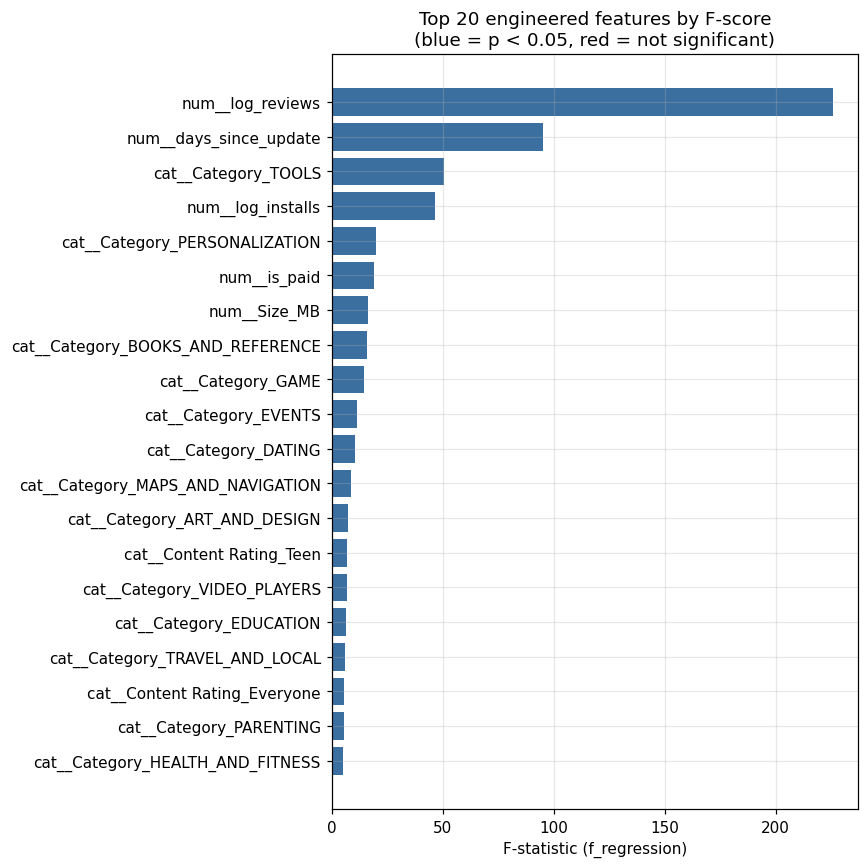

Saved: ../figures/07_feature_selection_scores.png


In [18]:
fig, ax = plt.subplots(figsize=(8, 8))
top20 = fs_table.head(20).iloc[::-1]
colors = ["#3b6fa0" if p < SIG_THRESHOLD else "#c0563b" for p in top20["p_value"]]
ax.barh(top20["feature"], top20["f_score"], color=colors)
ax.set_xlabel("F-statistic (f_regression)")
ax.set_title("Top 20 engineered features by F-score\n(blue = p < 0.05, red = not significant)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/07_feature_selection_scores.png", bbox_inches="tight")
plt.show()
print("Saved:", f"{FIGURES_DIR}/07_feature_selection_scores.png")


**Observation.** `log_reviews` and `days_since_update` are, by a wide margin,
the two strongest individual predictors, followed by a handful of `Category`
dummy variables (`TOOLS`, `PERSONALIZATION`, `GAME`, ...) and `log_installs`. This
is consistent with the raw correlation checks in `01` and Section 2.5 above — the
strongest signal in this dataset comes from usage-volume features and update
recency, not from any single feature dominating.


## 8. Dimensionality Reduction — PCA

**Method:** PCA on the standardized/encoded training matrix (`X_train_dense`,
already scaled for numeric columns via the fitted `ColumnTransformer`), **fit on
training data only**. PCA is explored here as a candidate dimensionality-reduction
step; whether it is actually kept in the final modelling pipeline is decided
**empirically in `04_modeling_and_tuning.ipynb`**, by comparing cross-validated
performance with and without it — not asserted here in advance.


In [19]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_dense)

evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

pca_variance_table = pd.DataFrame({
    "component": np.arange(1, len(evr) + 1),
    "explained_variance_ratio": evr,
    "cumulative_variance": cum_evr,
})
pca_variance_table.to_csv(f"{PROCESSED_DIR}/pca_explained_variance.csv", index=False)
print("Saved:", f"{PROCESSED_DIR}/pca_explained_variance.csv")

for target_var in [0.80, 0.90, 0.95]:
    n_comp = int(np.argmax(cum_evr >= target_var) + 1)
    print(f"Components needed for {target_var*100:.0f}% cumulative variance: {n_comp}")

pca_variance_table.head(10)


Saved: ../data/processed/pca_explained_variance.csv
Components needed for 80% cumulative variance: 5
Components needed for 90% cumulative variance: 9
Components needed for 95% cumulative variance: 18


,component,explained_variance_ratio,cumulative_variance
0,1,0.316584,0.316584
1,2,0.160497,0.477081
2,3,0.134014,0.611095
3,4,0.121484,0.732579
4,5,0.094492,0.827072
5,6,0.031432,0.858504
6,7,0.022748,0.881252
7,8,0.010984,0.892236
8,9,0.010009,0.902245
9,10,0.009482,0.911727


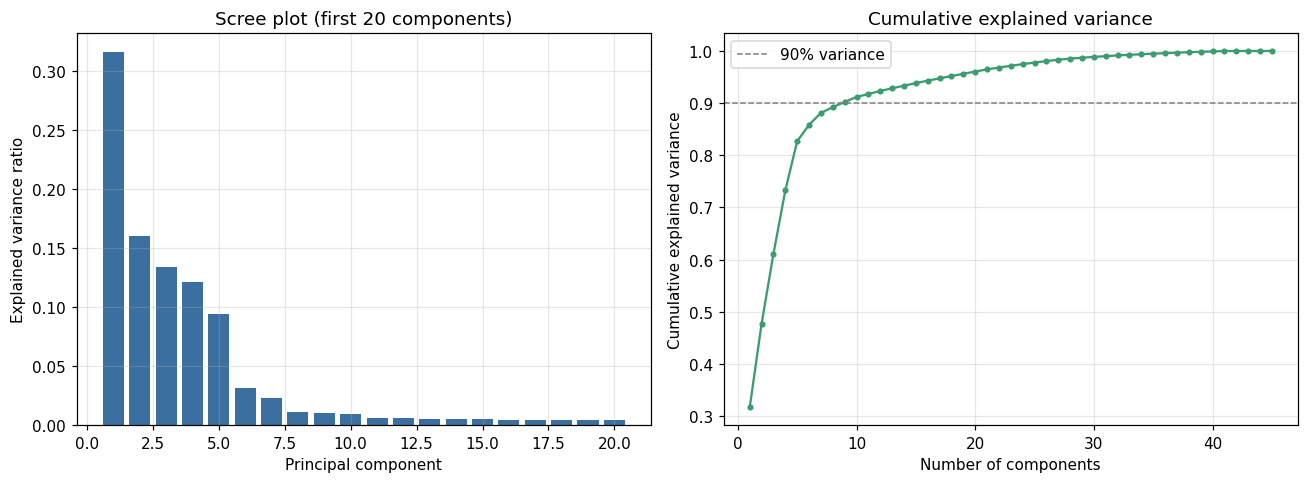

Saved: ../figures/08_pca_explained_variance.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(pca_variance_table["component"][:20], pca_variance_table["explained_variance_ratio"][:20],
            color="#3b6fa0")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree plot (first 20 components)")

axes[1].plot(pca_variance_table["component"], pca_variance_table["cumulative_variance"],
             marker="o", markersize=3, color="#3b9c6f")
axes[1].axhline(0.90, color="gray", linestyle="--", linewidth=1, label="90% variance")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative explained variance")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/08_pca_explained_variance.png", bbox_inches="tight")
plt.show()
print("Saved:", f"{FIGURES_DIR}/08_pca_explained_variance.png")


**Observation (variance structure only — no performance claim).** The first 5
components already explain roughly 80% of total variance, and 9 components explain
roughly 90%, compressing the 45-dimensional encoded space considerably. This is
expected: the 6 numeric features (already standardized, so each contributes
comparable variance) and the sparse one-hot `Category`/`Content Rating` dummies
combine to concentrate variance in a fairly small number of directions. **This
does not by itself mean PCA will help prediction** — it only describes how the
variance is distributed. Whether a PCA-reduced representation is retained in the
final model pipeline is decided empirically in `04_modeling_and_tuning.ipynb` by
comparing cross-validated scores with and without it, per the faculty instruction
not to claim a benefit without evidence.


In [21]:
# A reduced representation at the 90%-variance threshold, for comparison purposes.
N_COMPONENTS_90 = int(np.argmax(cum_evr >= 0.90) + 1)
pca_90 = PCA(n_components=N_COMPONENTS_90, random_state=RANDOM_STATE)
X_train_pca = pca_90.fit_transform(X_train_dense)
X_test_pca = pca_90.transform(X_test_dense)

print(f"PCA-reduced representation: {N_COMPONENTS_90} components "
      f"(vs. {X_train_dense.shape[1]} full engineered dimensions)")
print("Train shape:", X_train_pca.shape, " Test shape:", X_test_pca.shape)


PCA-reduced representation: 9 components (vs. 45 full engineered dimensions)
Train shape: (6556, 9)  Test shape: (1640, 9)


## 9. Comparison: Full Feature Space vs. Selected Features vs. PCA-Reduced

A single summary table comparing the three representations produced in this
notebook, for use in report Section 4.


In [22]:
comparison_table = pd.DataFrame([
    {
        "representation": "Full engineered feature space",
        "n_dimensions": X_train_dense.shape[1],
        "description": f"{len(numeric_features)} numeric + one-hot encoded "
                        f"{', '.join(categorical_features)}",
    },
    {
        "representation": "Selected features (f_regression, p < 0.05)",
        "n_dimensions": int(n_selected),
        "description": "Univariate F-test on training data only; statistically "
                        "significant features retained",
    },
    {
        "representation": "PCA-reduced (90% variance)",
        "n_dimensions": N_COMPONENTS_90,
        "description": "Principal components fit on training data only, retaining "
                        "~90% of total variance",
    },
])
comparison_table.to_csv(f"{PROCESSED_DIR}/feature_representation_comparison.csv", index=False)
print("Saved:", f"{PROCESSED_DIR}/feature_representation_comparison.csv")
comparison_table


Saved: ../data/processed/feature_representation_comparison.csv


,representation,n_dimensions,description
0,Full engineered feature space,45,"6 numeric + one-hot encoded Category, Content ..."
1,"Selected features (f_regression, p < 0.05)",22,Univariate F-test on training data only; stati...
2,PCA-reduced (90% variance),9,Principal components fit on training data only...


## 10. Save the Final Feature-Engineered Table

The engineered (but not yet encoded/scaled/selected) table is saved so that
`04_modeling_and_tuning.ipynb` can load it directly and rebuild the same
`ColumnTransformer` + feature-selection/PCA steps **inside a single `sklearn`
`Pipeline`**, refitting everything from the training split forward — this notebook's
`X_train_enc`/`X_test_enc` matrices are for diagnostic comparison only and are not
themselves reused as the modelling input, to keep the actual model-fitting pipeline
self-contained and leakage-safe in one place.


In [23]:
engineered_columns = ["App", "Rating"] + feature_columns
df_features = df[engineered_columns].copy()

FEATURES_OUTPUT_PATH = f"{PROCESSED_DIR}/googleplaystore_features.csv"
df_features.to_csv(FEATURES_OUTPUT_PATH, index=False)
print("Saved:", FEATURES_OUTPUT_PATH)
print("Shape:", df_features.shape)
df_features.head()


Saved: ../data/processed/googleplaystore_features.csv
Shape: (8196, 10)


,App,Rating,log_reviews,log_installs,Size_MB,Price_USD,is_paid,days_since_update,Category,Content Rating
0,Photo Editor & Candy Camera & Grid & ScrapBook,4.1,5.075174,9.210440,19.0,0.0,0,214,ART_AND_DESIGN,Everyone
1,"U Launcher Lite – FREE Live Cool Themes, Hide ...",4.7,11.379520,15.424949,8.7,0.0,0,8,ART_AND_DESIGN,Everyone
2,Sketch - Draw & Paint,4.5,12.281389,17.727534,25.0,0.0,0,62,ART_AND_DESIGN,Teen
3,Pixel Draw - Number Art Coloring Book,4.3,6.875232,11.512935,2.8,0.0,0,50,ART_AND_DESIGN,Everyone
4,Paper flowers instructions,4.4,5.123964,10.819798,5.6,0.0,0,501,ART_AND_DESIGN,Everyone


## 11. Summary of Feature-Engineering Decisions

| Decision | Outcome |
|---|---|
| Derived features created | `log_reviews`, `log_installs`, `is_paid`, `days_since_update`, `Size_MB` (reused from `02`) |
| Derived feature rejected | `last_updated_year` — redundant with `days_since_update` |
| Categorical predictors kept | `Category` (33 levels), `Content Rating` (6 levels, imbalanced but handled via `handle_unknown='ignore'`) |
| Categorical predictors dropped | `Type` (redundant with `is_paid`), `Genres` (redundant with `Category`, unjustifiably high cardinality: 114 vs 33 levels) |
| Other columns dropped | `App` (identifier), `Current Ver` / `Android Ver` (high-cardinality version strings, not in approved research questions), raw string/duplicate numeric columns superseded by parsed/derived versions |
| Final candidate feature columns | 6 numeric + 2 categorical -> 45 dimensions after one-hot encoding |
| Train/test split | 80/20, `random_state=42`, performed **before** any learned transformation |
| Preprocessing | `ColumnTransformer` (median imputation + `StandardScaler` for numeric; most-frequent imputation + `OneHotEncoder(handle_unknown='ignore')` for categorical), fit on training data only |
| Feature selection | `f_regression` via `SelectKBest`, `p < 0.05` threshold, fit on training data only -- retains 22 of 45 dimensions |
| Dimensionality reduction | PCA fit on training data only; 5 components ~= 80% variance, 9 ~= 90%, 18 ~= 95% |
| PCA retained for modelling? | **Not decided here.** Deferred to `04_modeling_and_tuning.ipynb`, where it will be compared empirically (cross-validated performance with vs. without PCA) before any claim is made. |

All learned statistics (imputer fill values, scaler mean/std, encoder category
lists, feature-selection scores, PCA components) were fit on `X_train`/`y_train`
only; `X_test`/`y_test` were only ever transformed, never used to fit anything, in
line with the project's leakage-prevention rule.
